In [24]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from scipy.stats import ks_2samp
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

In [25]:
df_path = Path(f"{os.getcwd()}/../data/preprocessed_train.csv")
df = pd.read_csv(df_path)

In [26]:
df.head()

,Unnamed: 0,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,REGION_POPULATION_RELATIVE,...,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,"AGE_BUCKET_(20, 30]","AGE_BUCKET_(30, 40]","AGE_BUCKET_(40, 50]","AGE_BUCKET_(50, 60]","AGE_BUCKET_(60, 70]","AGE_BUCKET_(70, 100]"
0,0,100002,1,0,202500.0,406597.5,24700.5,351000.0,2,0.018801,...,0,0,0,1,1,0,0,0,0,0
1,1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,4,0.003541,...,0,0,0,0,0,0,1,0,0,0
2,2,100004,0,0,67500.0,135000.0,6750.0,135000.0,2,0.010032,...,0,0,0,0,0,0,0,1,0,0
3,3,100006,0,0,135000.0,312682.5,29686.5,297000.0,2,0.008019,...,0,0,0,1,0,0,0,1,0,0
4,4,100007,0,0,121500.0,513000.0,21865.5,513000.0,2,0.028663,...,0,1,0,0,0,0,0,1,0,0


In [27]:
# split into features and target
X, y = df.drop(columns=['TARGET', 'SK_ID_CURR', 'Unnamed: 0']), df['TARGET']

# the target column is not a feature, the SK_ID_CURR is an identifier, and the AGE_BUCKET is not numerical

# split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Define a function to evaluate the model

What to include:
- Best F1 threshold score
- KS statistic
- AUPRC (average precision)
- AUROC
- Gini

In [28]:
# function will take trained model, along with test data, and produce dataframe with results

def evaluate_model(algorithm, model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    # auroc
    auroc = roc_auc_score(y_test, y_prob)
    # gini
    gini = (2 * auroc) - 1
    # ks
    ks = ks_2samp(y_prob[y_test == 0], y_prob[y_test == 1]).statistic
    # auprc
    auprc = average_precision_score(y_test, y_prob)
    # optimal threshold for f1
    thresholds = np.arange(0.01, 1.00, 0.01)
    best_threshold = 0.5
    best_f1 = 0

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        f1 = f1_score(y_test, y_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    # get info to be able to plot ROC and PR curves
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
    precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

    return {
        "Model": algorithm,
        "AUROC": auroc,
        "Gini": gini,
        "KS": ks,
        "AUPRC": auprc,
        "Best Threshold": best_threshold,
        "F1": best_f1,
        "ROC Curve": (fpr, tpr, roc_thresholds),
        "PR Curve": (precision, recall, pr_thresholds)
    }

In [29]:
def display_results(results):
    display({k: v for k, v in results.items() if k not in ['ROC Curve', 'PR Curve']})

### Create Pipeline 

In [30]:
numeric_cols = X_train.select_dtypes(include="number").columns

# numeric columns will be standardized
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols)]
)

### Logistic Regression Baseline

In [31]:
lr_pipeline = Pipeline(
    [('preprocesser', preprocessor),
    ('model', LogisticRegression(C=0.1, max_iter=1000, class_weight='balanced'))
    ]
)

lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocesser', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
lr_results = evaluate_model("Logistic Regression", lr_pipeline, X_test, y_test)
display_results(lr_results)

{'Model': 'Logistic Regression',
 'AUROC': 0.7540917805301441,
 'Gini': 0.5081835610602883,
 'KS': 0.38017888992447285,
 'AUPRC': 0.24072424056937702,
 'Best Threshold': 0.67,
 'F1': 0.3053945608559964}

### Random Forest

In [33]:
random_forest_pipeline = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced'))
    ]
)

random_forest_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
rf_results = evaluate_model("Random Forest", random_forest_pipeline, X_test, y_test)
display_results(rf_results)

{'Model': 'Random Forest',
 'AUROC': 0.750329486354248,
 'Gini': 0.500658972708496,
 'KS': 0.37475862823698824,
 'AUPRC': 0.23330216967632952,
 'Best Threshold': 0.6,
 'F1': 0.295422922006591}

### XGBoost

In [35]:
xgboost_pipeline = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(n_estimators=200, max_depth=20, scale_pos_weight=1))
    ]
)

xgboost_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
xgboost_results = evaluate_model("XGBoost", xgboost_pipeline, X_test, y_test)
display_results(xgboost_results)

{'Model': 'XGBoost',
 'AUROC': 0.7281371720975692,
 'Gini': 0.45627434419513846,
 'KS': 0.33968827104386334,
 'AUPRC': 0.21206497444991473,
 'Best Threshold': 0.02,
 'F1': 0.2808369212176146}

### Comparison table of all models + all results

In [37]:
comparison_df = pd.DataFrame([lr_results, rf_results, xgboost_results]).drop(columns=['ROC Curve', 'PR Curve'])
display(comparison_df)

,Model,AUROC,Gini,KS,AUPRC,Best Threshold,F1
0,Logistic Regression,0.754092,0.508184,0.380179,0.240724,0.67,0.305395
1,Random Forest,0.750329,0.500659,0.374759,0.233302,0.60,0.295423
2,XGBoost,0.728137,0.456274,0.339688,0.212065,0.02,0.280837


Baseline Logistic Regression comes out on top for both AUROC and AUPRC

### Plotting curves

#### First figure - ROC curve

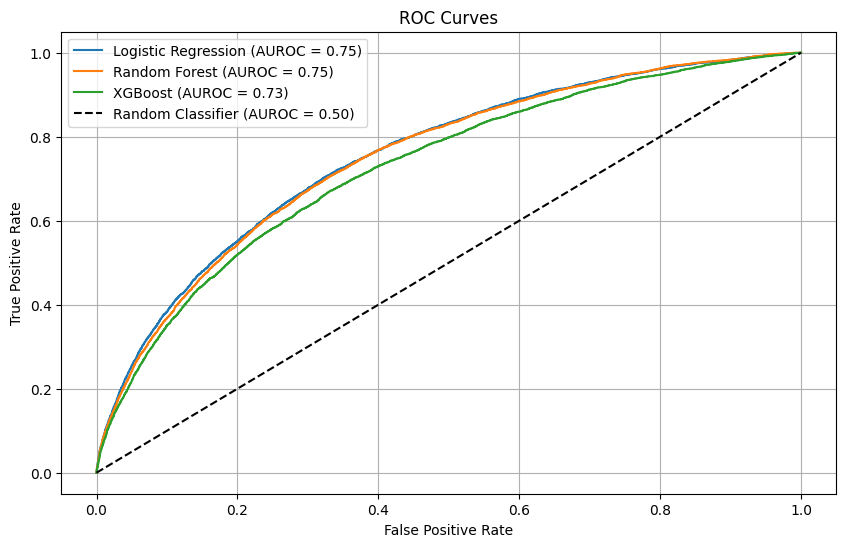

In [38]:
def plot_roc_curves():
    plt.figure(figsize=(10, 6))
    for results in [lr_results, rf_results, xgboost_results]:
        fpr, tpr, _ = results['ROC Curve']
        plt.plot(fpr, tpr, label=f"{results['Model']} (AUROC = {results['AUROC']:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUROC = 0.50)')
    plt.title('ROC Curves')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid()
    plt.show()

plot_roc_curves()

#### Second figure - Precision Recall Curve

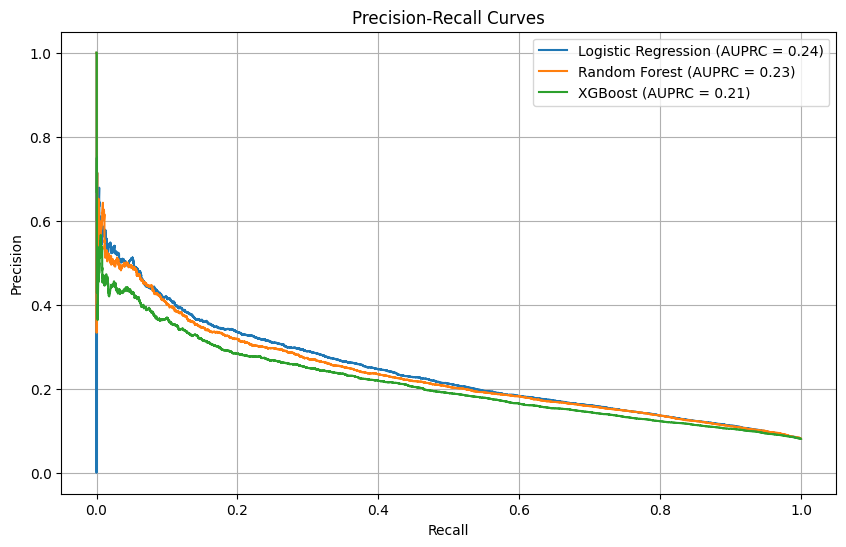

In [39]:
def plot_precision_recall_curves():
    plt.figure(figsize=(10, 6))
    for results in [lr_results, rf_results, xgboost_results]:
        precision, recall, _ = results['PR Curve']
        plt.plot(recall, precision, label=f"{results['Model']} (AUPRC = {results['AUPRC']:.2f})")
    plt.title('Precision-Recall Curves')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid()
    plt.show()

plot_precision_recall_curves()

### Stratified K-Fold CV

Here we will use cross-validation to determine the best model. This involves training each model across 5 folds (splits), then taking the mean and std of AUROC across folds

In [40]:
pipelines = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': random_forest_pipeline,
    'XGBoost': xgboost_pipeline
}

# define one cv object and use across all pipelines so that differences are due to the models and not the data
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [41]:
%%time

def cross_validate(results_dict, pipelines, X_train, y_train, cv_object):
    scores_path = Path(f"{os.getcwd()}/../data/cross_val_scores.npy")

    # Load cached results if they exist
    if scores_path.exists():
        return np.load(scores_path, allow_pickle=True).item()

    # Otherwise compute cross-validation scores
    for name, pipeline in pipelines.items():
        scores = cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv=cv_object,
            scoring="roc_auc"
        )

        results_dict[name] = {
            "Mean AUROC": np.mean(scores),
            "Std AUROC": np.std(scores)
        }

    # Save results for future use
    scores_path.parent.mkdir(parents=True, exist_ok=True)
    np.save(scores_path, results_dict)

    return results_dict


k_folds_cv_results = cross_validate({}, pipelines, X, y, cv)

CPU times: total: 35min 43s
Wall time: 11min 51s


In [42]:
k_folds_cv_results

{'Logistic Regression': {'Mean AUROC': 0.7523257331557007,
  'Std AUROC': 0.004743993045532736},
 'Random Forest': {'Mean AUROC': 0.7473394898062914,
  'Std AUROC': 0.0046681710770259755},
 'XGBoost': {'Mean AUROC': 0.7277015476519597,
  'Std AUROC': 0.0034282965750867525}}

### RandomizedSearchCV

In [43]:
param_grid = {
    "model__C": [0.001, 0.01, 0.1],
    "model__penalty": ['l2']
,    "model__class_weight": ["balanced"],
    "model__max_iter": [1000]
}

search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=2,
    verbose=2
)

In [44]:
%%time
search.fit(X, y)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
CPU times: total: 36.6 s
Wall time: 53.1 s


,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'model__C': [0.001, 0.01, ...], 'model__class_weight': ['balanced'], 'model__max_iter': [1000], 'model__penalty': ['l2']}"
,scoring,'roc_auc'
,n_jobs,2
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...)]"


In [45]:
print("Best AUROC:", search.best_score_)
print("Best params:", search.best_params_)

Best AUROC: 0.7523257338681894
Best params: {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__max_iter': 1000, 'model__penalty': 'l2'}


### Saving the model using joblib

In [46]:
import joblib
model_path = Path(f"{os.getcwd()}/../models/best_model.pkl")
joblib.dump(search.best_estimator_, model_path)

['c:\\Users\\alann\\OneDrive\\Desktop\\Coding\\Jarvis Talent Incubation Training\\jarvis_data_eng_AlanHu\\machine_learning\\module1\\capstone\\notebooks\\..\\models\\best_model.pkl']